# Predicting Significant Stock Price Movements Using Machine Learning
**DS 4400: Machine Learning and Data Mining I — Spring 2026**  
**Author:** Hailey Salce

### Project Overview
The goal of my project was to predict whether an S&P 500 stock will experience a significant price movement (daily return ≥ 2%) on the next trading day

| Class | Meaning |
|---|---|
| **0** | No significant move (small daily fluctuation) |
| **1** | Significant move (\|return\| ≥ 2% next day) |

## 0. Imports & Setup

In [79]:
import warnings
warnings.filterwarnings("ignore")
import logging
logging.getLogger("shap").setLevel(logging.ERROR)

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import yfinance as yf

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score,
    ConfusionMatrixDisplay, RocCurveDisplay
)
from sklearn.metrics import precision_recall_curve
from sklearn.utils import resample

from scipy import stats
import shap

%matplotlib inline
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "sans-serif",
})

## 1. Configuration
All tunable parameters are defined here so they can be changed in one place

In [6]:
RANDOM_STATE = 42
N_SPLITS = 5      
THRESHOLD = 0.02    
START_DATE = "2015-01-01"
END_DATE = "2024-12-31"

# 30 S&P 500 tickers: 6 sectors (Tech, Finance, Healthcare, Energy, Consumer, and Industrials), 5 per sector
SP500_SAMPLE = [
    "AAPL", "MSFT", "GOOGL", "AMZN", "NVDA",   
    "JPM", "BAC", "GS", "MS", "WFC",      
    "JNJ", "PFE", "MRK", "ABT", "UNH",      
    "XOM", "CVX", "COP", "SLB", "EOG",      
    "WMT", "TGT", "COST", "HD", "NKE",      
    "BA", "GE", "MMM", "CAT", "HON",      
]

FEATURE_COLS = [
    "ma5_20_ratio", "ma20_50_ratio",
    "rsi14",
    "macd", "macd_signal", "macd_hist",
    "bb_pct_b", "bb_width",
    "daily_return", "volatility_5d", "volatility_20d",
    "vol_ratio",
]

## 2. Data Collection
Download daily OHLCV data for all 30 tickers via yfinance and put them into a single df

In [7]:
def download_data(tickers, start, end):
    raw = yf.download(tickers, start=start, end=end, auto_adjust=True, progress=False)

    frames = []
    for ticker in tickers:
        try:
            df = raw.xs(ticker, axis=1, level=1).copy()
            df.columns = [c.lower() for c in df.columns]
            df["ticker"] = ticker
            df = df.dropna()
            frames.append(df)
        except Exception:
            pass

    combined = pd.concat(frames).sort_index()
    return combined

In [8]:
raw_df = download_data(SP500_SAMPLE, START_DATE, END_DATE)
raw_df.head()

,close,high,low,open,volume,ticker
Date,,,,,,
2015-01-02,24.214886,24.682218,23.776346,24.671143,212818400,AAPL
2015-01-02,26.260456,26.570394,26.177639,26.411704,26480000,GOOGL
2015-01-02,15.426000,15.737500,15.348000,15.629000,55664000,AMZN
2015-01-02,69.158569,69.527399,68.240274,69.075771,3767900,CAT
2015-01-02,0.482985,0.486584,0.475307,0.482985,113680000,NVDA


## 3. Feature Engineering
Compute 12 technical indicators per ticker from the raw OHLCV data, then define the binary classification target

| Feature | Description |
|---|---|
| `ma5_20_ratio` | 5-day MA / 20-day MA - short-term trend direction |
| `ma20_50_ratio` | 20-day MA / 50-day MA — medium-term trend direction |
| `rsi14` | RSI over 14 days — overbought (>70) / oversold (<30) |
| `macd`, `macd_signal`, `macd_hist` | Momentum oscillator from 12/26-day EMAs |
| `bb_pct_b` | Where price sits within Bollinger Bands |
| `bb_width` | Bollinger Band width — volatility compression/expansion |
| `daily_return` | Previous day's % price change |
| `volatility_5d`, `volatility_20d` | Rolling std of returns — volatility clustering |
| `vol_ratio` | Volume vs. 20-day average — unusual activity signal |

**Classification:** 1 if next_day_return ≥ 2%, else 0

In [9]:
def add_technical_features(df):
    results = []

    for ticker, grp in df.groupby("ticker"):
        g = grp.sort_index().copy()
        c = g["close"]

        # moving averages
        g["ma5"] = c.rolling(5).mean()
        g["ma20"] = c.rolling(20).mean()
        g["ma50"] = c.rolling(50).mean()
        g["ma5_20_ratio"] = g["ma5"]  / g["ma20"]
        g["ma20_50_ratio"] = g["ma20"] / g["ma50"]

        # RSI-14
        delta = c.diff()
        gain = delta.clip(lower=0).rolling(14).mean()
        loss = (-delta).clip(lower=0).rolling(14).mean()
        g["rsi14"] = 100 - (100 / (1 + gain / (loss + 1e-9)))

        # MACD
        ema12 = c.ewm(span=12, adjust=False).mean()
        ema26 = c.ewm(span=26, adjust=False).mean()
        g["macd"] = ema12 - ema26
        g["macd_signal"] = g["macd"].ewm(span=9, adjust=False).mean()
        g["macd_hist"] = g["macd"] - g["macd_signal"]

        # Bollinger Bands (20-period, 2 std)
        bb_mid = c.rolling(20).mean()
        bb_std = c.rolling(20).std()
        bb_upper = bb_mid + 2 * bb_std
        bb_lower = bb_mid - 2 * bb_std
        g["bb_pct_b"] = (c - bb_lower) / (bb_upper - bb_lower + 1e-9)
        g["bb_width"] = (bb_upper - bb_lower) / (bb_mid + 1e-9)

        # return and volatility
        g["daily_return"] = c.pct_change()
        g["volatility_5d"] = g["daily_return"].rolling(5).std()
        g["volatility_20d"] = g["daily_return"].rolling(20).std()

        # volume ratio
        g["vol_ratio"] = g["volume"] / (g["volume"].rolling(20).mean() + 1e-9)

        # significant move on NEXT day
        next_ret = c.pct_change().shift(-1)
        g["next_return"] = next_ret
        g["target"] = (next_ret.abs() >= THRESHOLD).astype(int)

        results.append(g)

    return pd.concat(results).sort_index()

In [10]:
def prepare_dataset(df):
    cols = FEATURE_COLS + ["target"]
    clean = df[cols].dropna()
    X = clean[FEATURE_COLS].values
    y = clean["target"].values
    return X, y, clean

In [12]:
df_feat = add_technical_features(raw_df)
X, y, clean = prepare_dataset(df_feat)

print(f"Dataset balance : {y.mean():.2%} positive (significant moves)")
clean.describe().round(4)

Dataset balance : 18.56% positive (significant moves)


,ma5_20_ratio,ma20_50_ratio,rsi14,macd,macd_signal,macd_hist,bb_pct_b,bb_width,daily_return,volatility_5d,volatility_20d,vol_ratio,target
count,73980.0000,73980.0000,73980.0000,73980.0000,73980.0000,73980.0000,73980.0000,73980.0000,73980.0000,73980.0000,73980.0000,73980.0000,73980.0000
mean,1.0040,1.0080,53.2103,0.4365,0.4376,-0.0011,0.5513,0.1145,0.0007,0.0153,0.0165,1.0082,0.1856
std,0.0360,0.0451,17.2091,2.7681,2.5909,0.8542,0.3252,0.0807,0.0191,0.0116,0.0097,0.4179,0.3887
min,0.5000,0.5732,0.6896,-56.9947,-47.8454,-16.1047,-0.5317,0.0079,-0.3201,0.0002,0.0025,0.1406,0.0000
25%,0.9860,0.9842,40.9990,-0.4949,-0.4503,-0.2391,0.2913,0.0646,-0.0079,0.0082,0.0106,0.7639,0.0000
50%,1.0052,1.0092,53.4143,0.2400,0.2422,0.0036,0.5884,0.0944,0.0006,0.0125,0.0143,0.9209,0.0000
75%,1.0233,1.0331,65.7610,1.2220,1.1737,0.2517,0.8145,0.1404,0.0093,0.0188,0.0196,1.1376,0.0000
max,1.3220,1.2153,100.0000,23.8337,22.6345,9.7348,1.5257,1.5506,0.2981,0.1748,0.1399,9.0374,1.0000


## 4. Exploratory Data Analysis
Examine class imbalance, feature correlations, and how features differ between classes

### 4.1 Class Distribution & Daily Return Histograms

In [13]:
vc = clean["target"].value_counts()
print(f"Class 0 (no sig. move): {vc[0]:,}")
print(f"Class 1 (sig. move): {vc[1]:,}")
print(f"Imbalance ratio: {vc[0]/vc[1]:.2f}:1")

Class 0 (no sig. move): 60,253
Class 1 (sig. move): 13,727
Imbalance ratio: 4.39:1


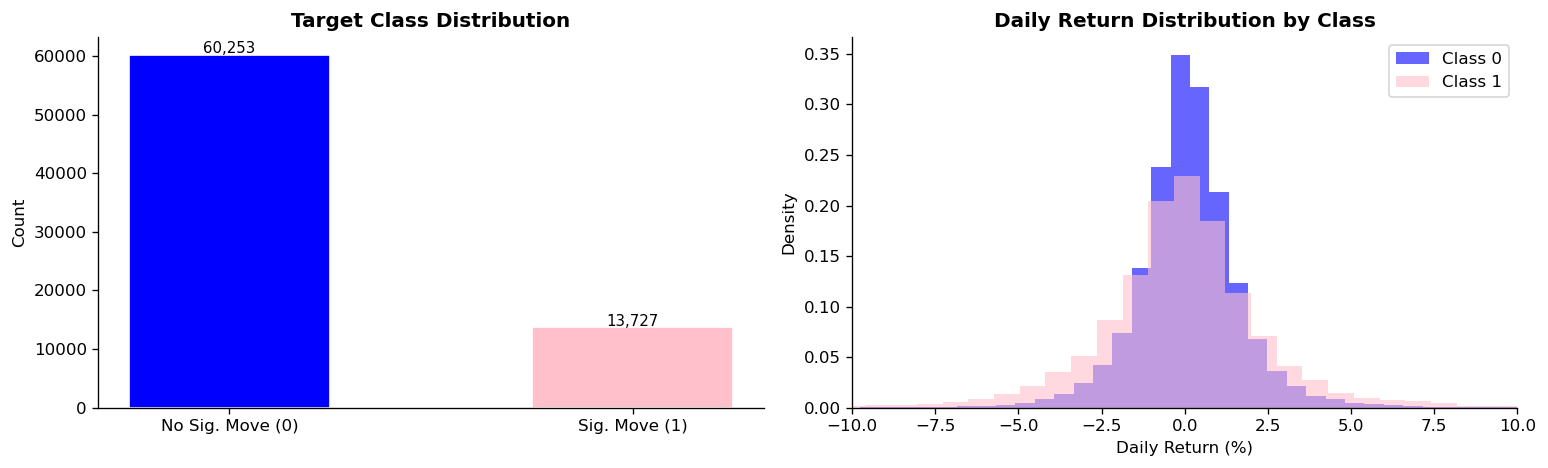

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# class distribution bar
axes[0].bar(["No Sig. Move (0)", "Sig. Move (1)"], [vc[0], vc[1]],
            color=["blue", "pink"], edgecolor="white", width=0.5)
axes[0].set_title("Target Class Distribution", fontweight="bold")
axes[0].set_ylabel("Count")
for i, v in enumerate([vc[0], vc[1]]):
    axes[0].text(i, v + 200, f"{v:,}", ha="center", fontsize=9)

# return distribution by class
c0 = clean.loc[clean["target"] == 0, "daily_return"].dropna() * 100
c1 = clean.loc[clean["target"] == 1, "daily_return"].dropna() * 100
axes[1].hist(c0, bins=80, alpha=0.6, label="Class 0", density=True, color="blue")
axes[1].hist(c1, bins=80, alpha=0.6, label="Class 1", density=True, color="pink")
axes[1].set_xlim(-10, 10)
axes[1].set_xlabel("Daily Return (%)")
axes[1].set_ylabel("Density")
axes[1].set_title("Daily Return Distribution by Class", fontweight="bold")
axes[1].legend()

plt.tight_layout()
plt.show()

### 4.2 Feature Correlation Matrix

In [23]:
corr = clean[FEATURE_COLS].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

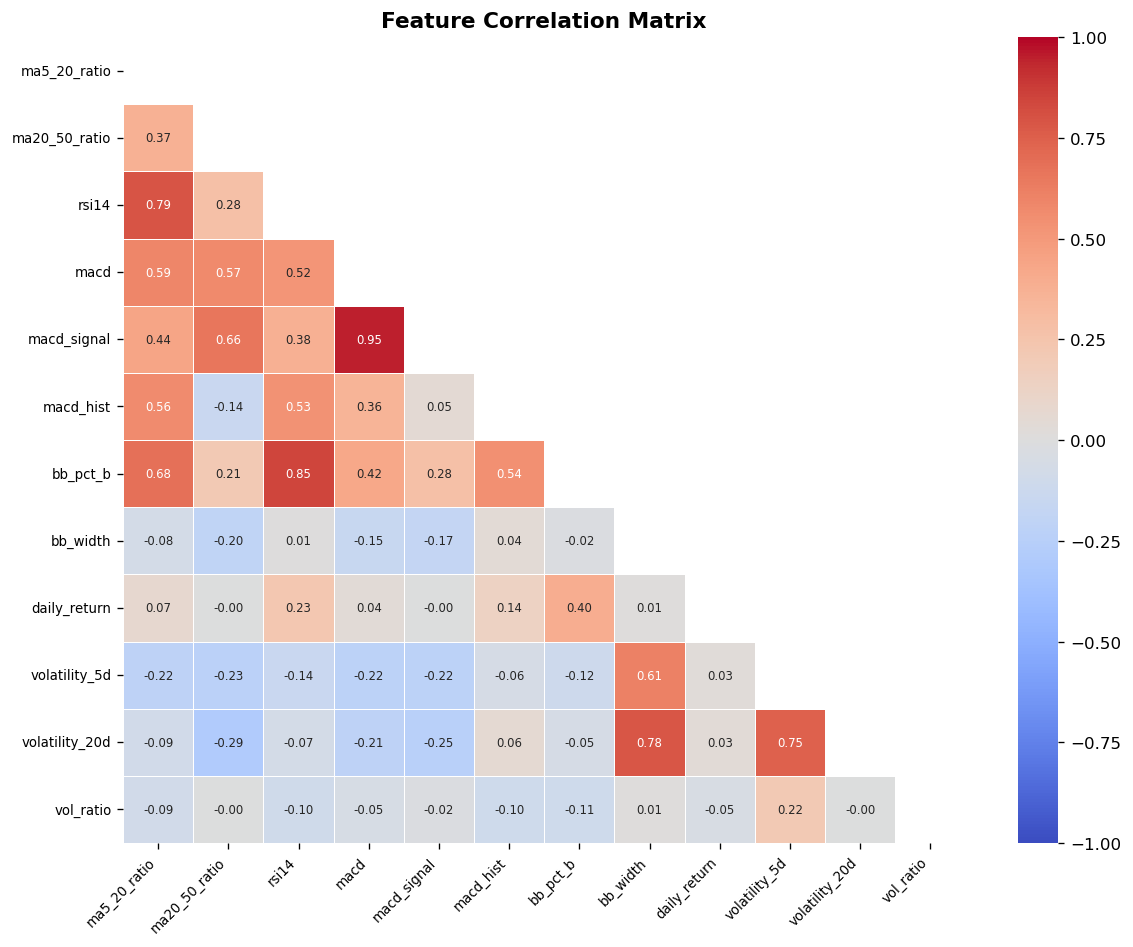

In [24]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, mask=mask, ax=ax, cmap="coolwarm", center=0,
            vmin=-1, vmax=1, annot=True, fmt=".2f", linewidths=0.4,
            xticklabels=FEATURE_COLS, yticklabels=FEATURE_COLS, annot_kws={"size": 7})
ax.set_title("Feature Correlation Matrix", fontweight="bold", fontsize=13)
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

### 4.3 Feature Distributions by Class

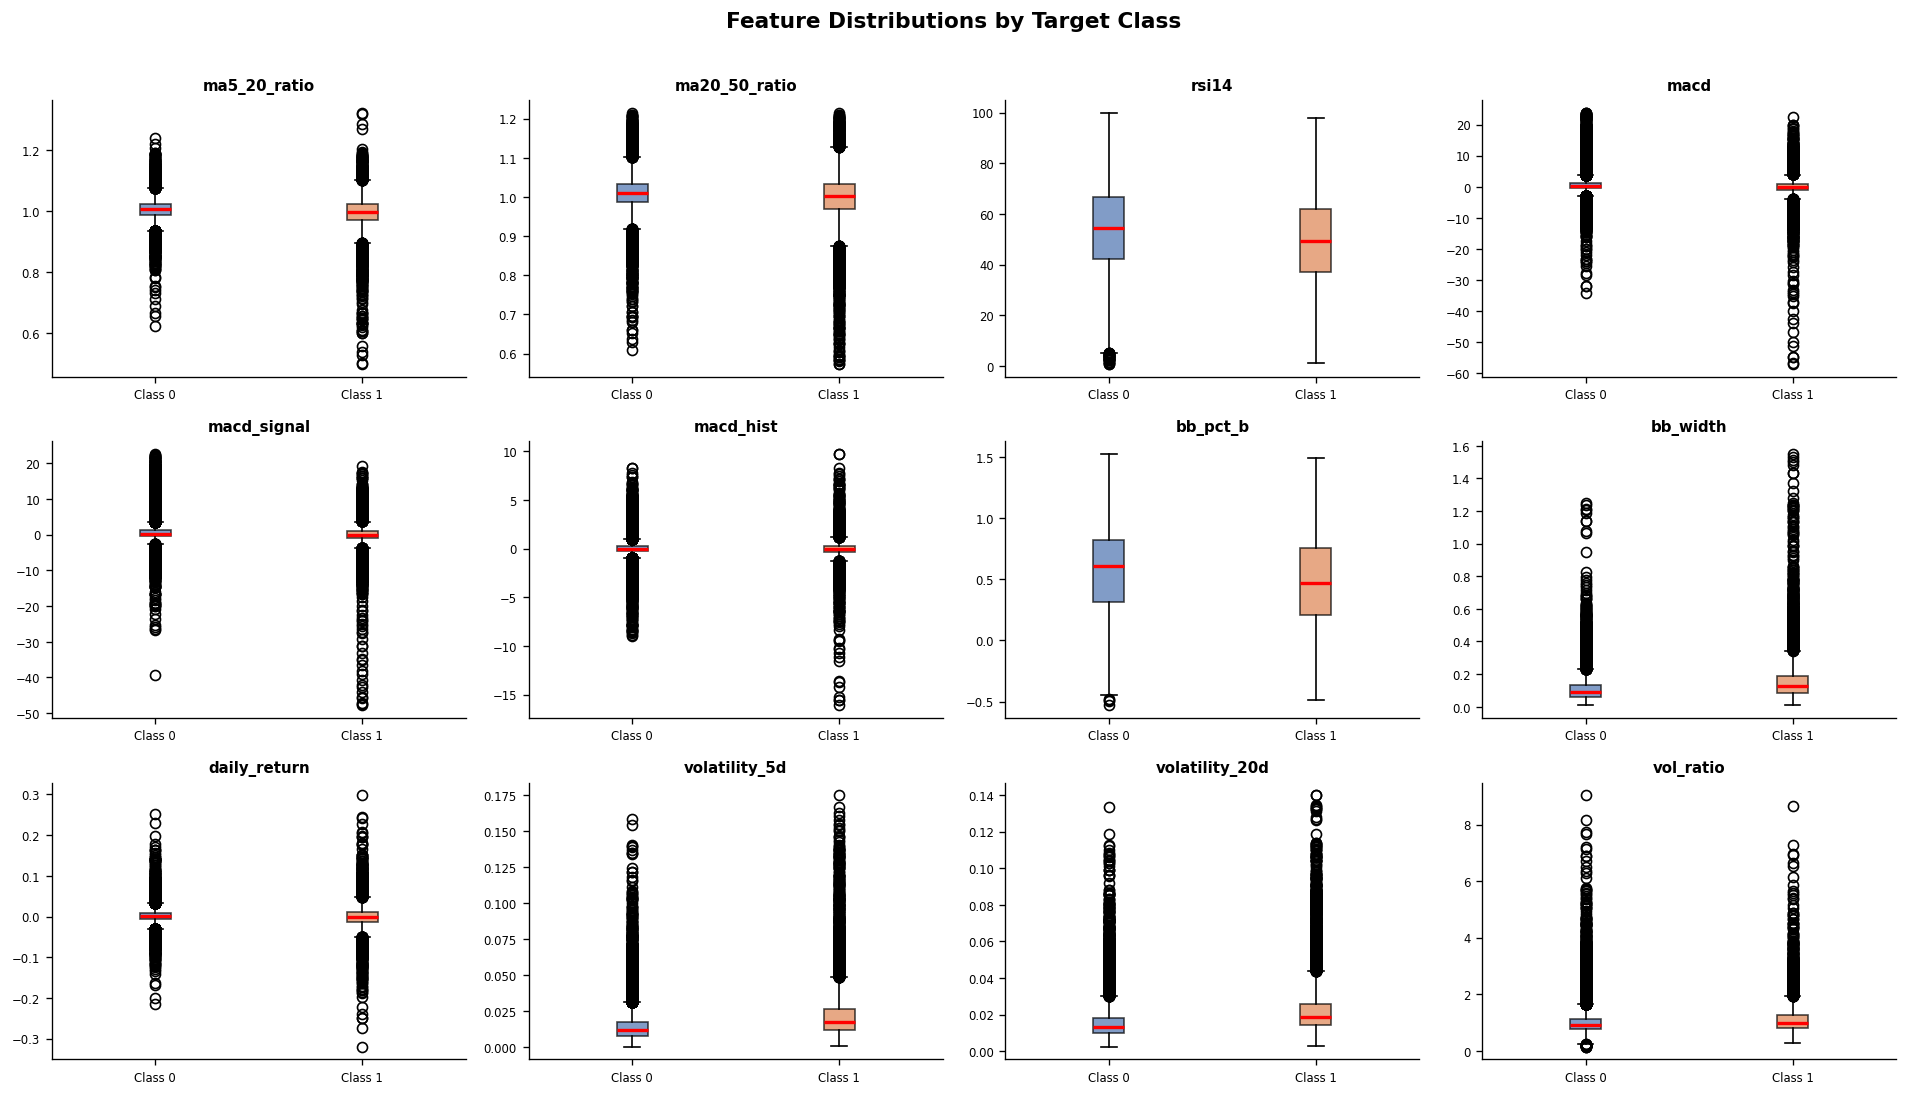

In [8]:
ncols = 4
nrows = (len(FEATURE_COLS) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3))
axes = axes.flatten()

for i, feat in enumerate(FEATURE_COLS):
    data_0 = clean.loc[clean["target"] == 0, feat].dropna()
    data_1 = clean.loc[clean["target1"] == 1, feat].dropna()
    bp = axes[i].boxplot(
        [data_0, data_1], labels=["Class 0", "Class 1"],
        patch_artist=True,
        boxprops=dict(alpha=0.7),
        medianprops=dict(color="red", linewidth=2),
    )
    bp["boxes"][0].set_facecolor("#4C72B0")
    bp["boxes"][1].set_facecolor("#DD8452")
    axes[i].set_title(feat, fontsize=9, fontweight="bold")
    axes[i].tick_params(labelsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Feature Distributions by Target Class", y=1.01, fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 5. Model Definitions
Throughout this project, 4 models are used. Each is wrapped in a Pipeline so that scaling is applied correctly within cross-validation folds to prevent data leakage.

In [27]:
def build_pipelines():
    return {
        "Logistic Regression": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(
                max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE
            )),
        ]),
        "kNN": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", KNeighborsClassifier(n_neighbors=11)),
        ]),
        "Random Forest": Pipeline([
            ("clf", RandomForestClassifier(
                n_estimators=200, max_depth=10,
                class_weight="balanced",
                random_state=RANDOM_STATE
            )),
        ]),
        "MLP": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", MLPClassifier(
                hidden_layer_sizes=(128, 64, 32),
                activation="relu", max_iter=300,
                early_stopping=True, validation_fraction=0.1,
                random_state=RANDOM_STATE
            )),
        ]),
    }

pipelines = build_pipelines()
print("Pipelines defined:", list(pipelines.keys()))

Pipelines defined: ['Logistic Regression', 'kNN', 'Random Forest', 'MLP']


## 6. Cross-Validation
5-fold Stratified K-Fold (preserves class ratios per fold) is used to compare models on F1-Score, ROC-AUC, and Accuracy.

In [32]:
def cross_validate_models(pipelines, X, y):
    cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    records = []

    for name, pipe in pipelines.items():
        f1_scores = cross_val_score(pipe, X, y, cv=cv, scoring="f1")
        roc_scores = cross_val_score(pipe, X, y, cv=cv, scoring="roc_auc")
        acc_scores = cross_val_score(pipe, X, y, cv=cv, scoring="accuracy")
        print(f"Cross-validated {name}")
        #print(f"F1={f1_scores.mean():.3f}±{f1_scores.std():.3f}  "
              #f"AUC={roc_scores.mean():.3f}±{roc_scores.std():.3f}")

        for fold_i, (f1, auc, acc) in enumerate(zip(f1_scores, roc_scores, acc_scores)):
            records.append({"model": name, "fold": fold_i + 1,
                            "f1": f1, "roc_auc": auc, "accuracy": acc})

    return pd.DataFrame(records)

In [33]:
cv_results = cross_validate_models(pipelines, X, y)

Cross-validated Logistic Regression
Cross-validated kNN
Cross-validated Random Forest
Cross-validated MLP


In [35]:
# Summary table
cv_summary = (
    cv_results.groupby("model")
    .agg({"f1": ["mean", "std"], "roc_auc": ["mean", "std"], "accuracy": ["mean", "std"]})
    .round(4)
)
cv_summary

f1         roc_auc         accuracy        
                       mean     std    mean     std     mean     std
model                                                               
Logistic Regression  0.4269  0.0065  0.7295  0.0050   0.7070  0.0024
MLP                  0.2000  0.0187  0.7337  0.0040   0.8227  0.0019
Random Forest        0.4306  0.0072  0.7324  0.0051   0.7068  0.0045
kNN                  0.2368  0.0073  0.6810  0.0077   0.8167  0.0026

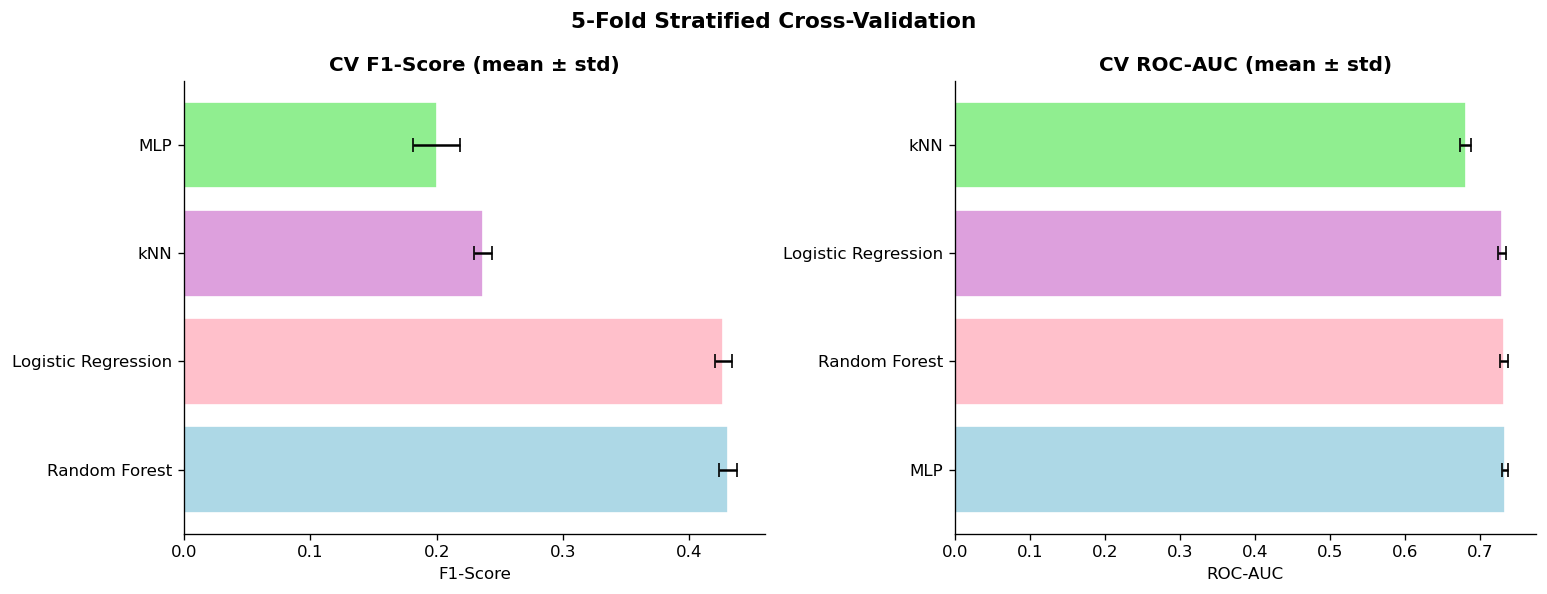

In [46]:
# visualize CV results
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
metrics = [("f1", "F1-Score"), ("roc_auc", "ROC-AUC")]
colors = ["lightblue", "pink", "plum", "lightgreen"]

for ax, (col, label) in zip(axes, metrics):
    means = cv_results.groupby("model")[col].mean()
    stds  = cv_results.groupby("model")[col].std()
    order = means.sort_values(ascending=False).index

    ax.barh(range(len(order)), means[order], xerr=stds[order],
            color=colors, capsize=4, edgecolor="white")
    ax.set_yticks(range(len(order)))
    ax.set_yticklabels(order)
    ax.set_xlabel(label)
    ax.set_title(f"CV {label} (mean ± std)", fontweight="bold")

plt.suptitle(f"{N_SPLITS}-Fold Stratified Cross-Validation", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 7. Statistical Tests
Pairwise paired t-tests were ran on each model's fold-level F1 scores, with Bonferroni correction to control the family-wise error rate

In [47]:
def statistical_tests(cv_results):
    models = cv_results["model"].unique()
    n_pairs = len(models) * (len(models) - 1) // 2
    rows = []

    for i, m1 in enumerate(models):
        for j, m2 in enumerate(models):
            if j <= i:
                continue
            s1 = cv_results.loc[cv_results["model"] == m1, "f1"].values
            s2 = cv_results.loc[cv_results["model"] == m2, "f1"].values
            t_stat, p_val = stats.ttest_rel(s1, s2)
            rows.append({
                "Model A": m1,
                "Model B": m2,
                "t-statistic": round(t_stat, 3),
                "p-value (raw)": round(p_val, 4),
                "p-value (Bonferroni)": round(min(p_val * n_pairs, 1.0), 4),
                "Significant": "Yes" if p_val * n_pairs < 0.05 else "No",
            })

    return pd.DataFrame(rows)

In [53]:
ttest_df = statistical_tests(cv_results)
ttest_df

,Model A,Model B,t-statistic,p-value (raw),p-value (Bonferroni),Significant
0,Logistic Regression,kNN,84.937,0.0000,0.0000,Yes
1,Logistic Regression,Random Forest,-3.701,0.0208,0.1249,No
2,Logistic Regression,MLP,22.987,0.0000,0.0001,Yes
3,kNN,Random Forest,-133.094,0.0000,0.0000,Yes
4,kNN,MLP,3.265,0.0309,0.1857,No
5,Random Forest,MLP,21.798,0.0000,0.0002,Yes


## 8. Final Evaluation on Hold-Out Test Set
A chronological 80/20 split (no shuffling) was used to simulate real trading conditions where models are trained on the past and evaluated on the future

In [56]:
split = int(0.8 * len(X))
X_train = X[:split]; y_train = y[:split]
X_test = X[split:]; y_test  = y[split:]

print(f"Train size: {len(X_train)} rows")
print(f"Test size: {len(X_test)} rows")
print(f"Test class balance: {y_test.mean():.2%} positive")

Train size: 59184 rows
Test size: 14796 rows
Test class balance: 15.21% positive


In [57]:
pipelines = build_pipelines()
summary = []
trained = {}

for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]
    trained[name] = pipe

    summary.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_prob),
    })

In [59]:
summary_df = pd.DataFrame(summary).set_index("Model")
summary_df

,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Logistic Regression,0.718573,0.241909,0.398667,0.301108,0.641822
kNN,0.837862,0.328736,0.063556,0.106518,0.594594
Random Forest,0.715734,0.239339,0.399111,0.299234,0.643411
MLP,0.847188,0.456693,0.025778,0.048801,0.655145


### 8.1 Confusion Matrices

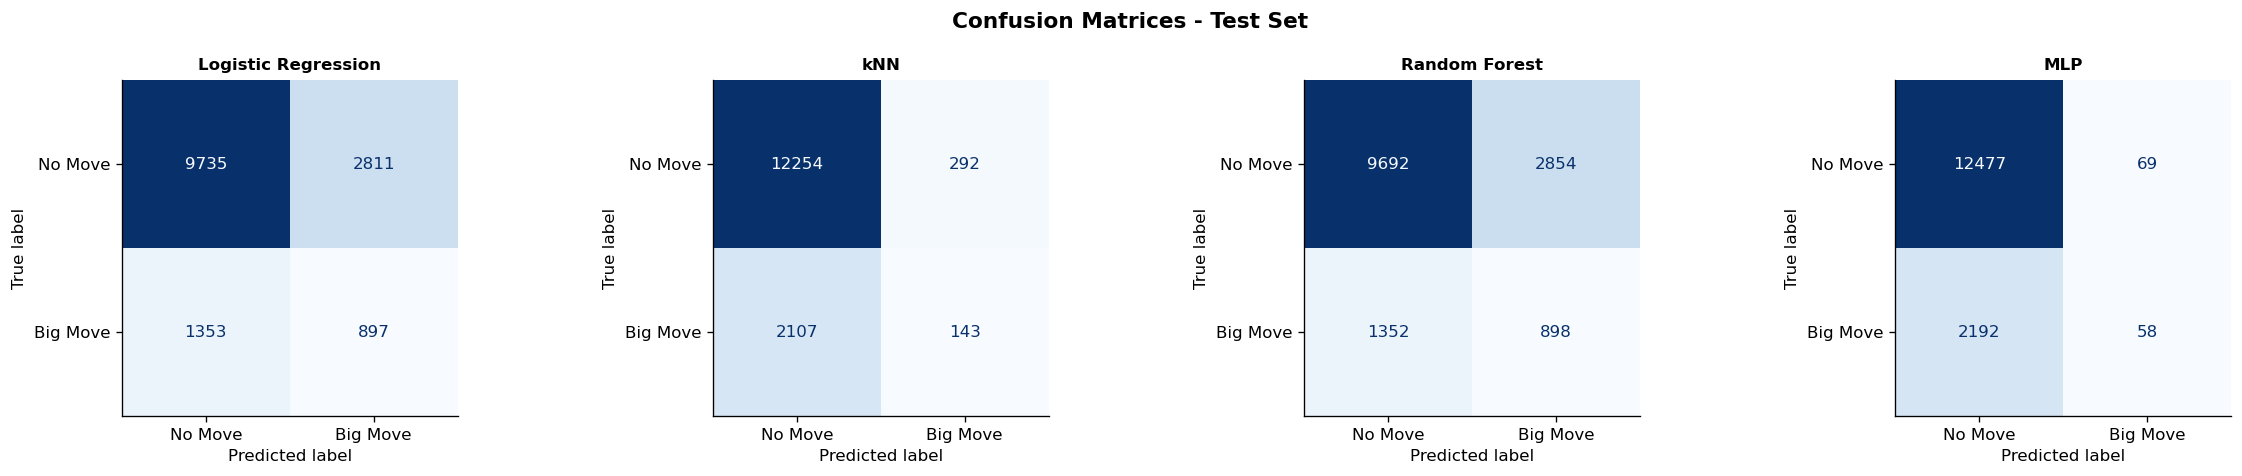

In [61]:
fig, axes = plt.subplots(1, len(trained), figsize=(5 * len(trained), 4))

for ax, (name, pipe) in zip(axes, trained.items()):
    y_pred = pipe.predict(X_test)
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred, ax=ax, colorbar=False,
        display_labels=["No Move", "Big Move"],
        cmap="Blues"
    )
    ax.set_title(name, fontsize=10, fontweight="bold")

fig.suptitle("Confusion Matrices - Test Set", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### 8.2 ROC Curves

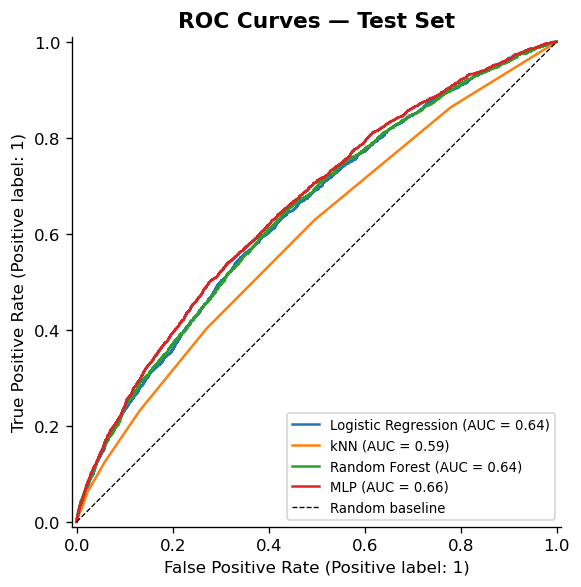

In [62]:
fig, ax = plt.subplots(figsize=(7, 5))

for name, pipe in trained.items():
    y_prob = pipe.predict_proba(X_test)[:, 1]
    RocCurveDisplay.from_predictions(y_test, y_prob, ax=ax, name=name)

ax.plot([0, 1], [0, 1], "k--", lw=0.8, label="Random baseline")
ax.set_title("ROC Curves — Test Set", fontsize=13, fontweight="bold")
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

## 9. SHAP Feature Importance
SHAP assigns each feature a contribution score for every prediction. Unlike raw logistic regression coefficients (which are confounded by feature scale and assume linearity), SHAP values are:
- Scale-invariant: comparable across features regardless of units
- Non-linear aware: correctly handle interactions for tree models
- Locally faithful: explain individual predictions, not just global averages

### 9.1 Random Forest — SHAP Bar Chart (Mean |SHAP|)

In [63]:
rf_clf = trained["Random Forest"].named_steps["clf"]
sample = shap.sample(X_test, 500, random_state=RANDOM_STATE)

explainer = shap.TreeExplainer(rf_clf)
shap_vals = explainer.shap_values(sample)
sv = shap_vals[1] if isinstance(shap_vals, list) else shap_vals

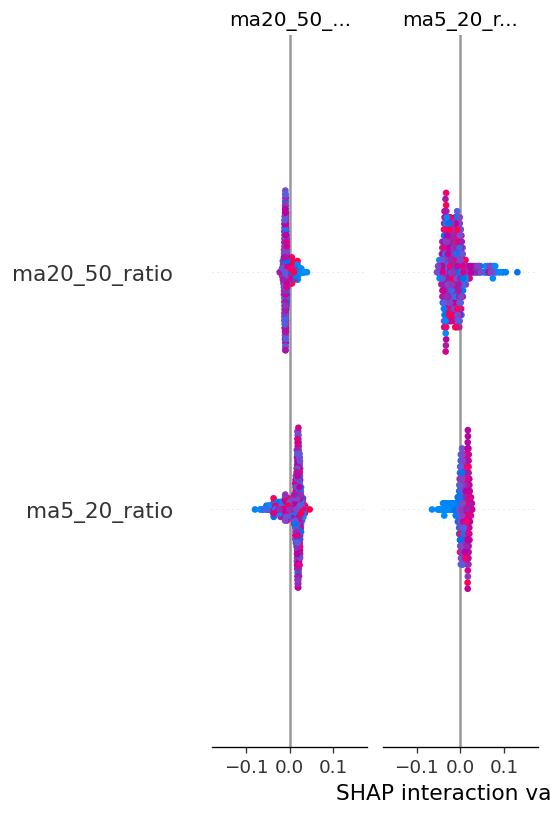

In [64]:
shap.summary_plot(sv, sample, feature_names=FEATURE_COLS, plot_type="bar", show=True)

### 9.2 Random Forest — SHAP Beeswarm Plot

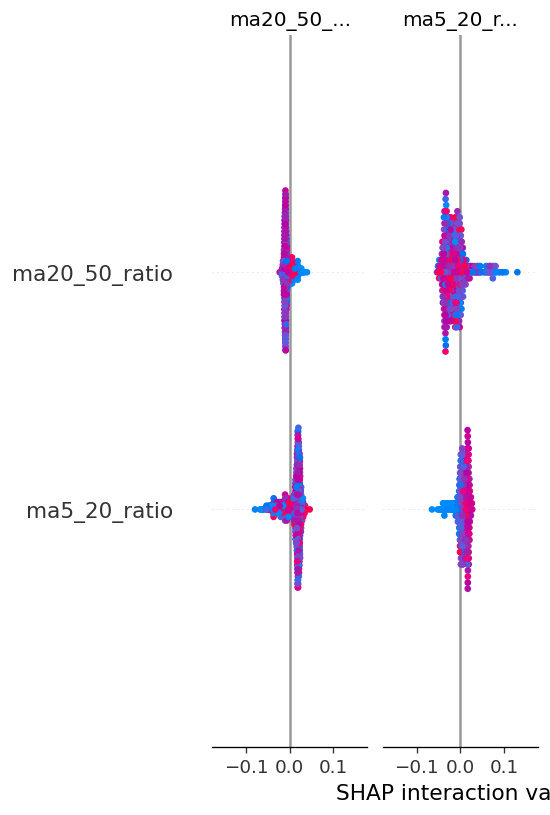

In [65]:
shap.summary_plot(sv, sample, feature_names=FEATURE_COLS, show=True)

### 9.3 Logistic Regression — SHAP Bar Chart

In [68]:
lr_pipe = trained["Logistic Regression"]
lr_scaler = lr_pipe.named_steps["scaler"]
lr_clf = lr_pipe.named_steps["clf"]

X_train_scaled = lr_scaler.transform(X_train)
X_test_scaled = lr_scaler.transform(X_test)

bg_lr = shap.sample(X_train_scaled, 200, random_state=RANDOM_STATE)
lr_explainer = shap.LinearExplainer(lr_clf, bg_lr)
lr_shap_vals = lr_explainer.shap_values(X_test_scaled[:500])

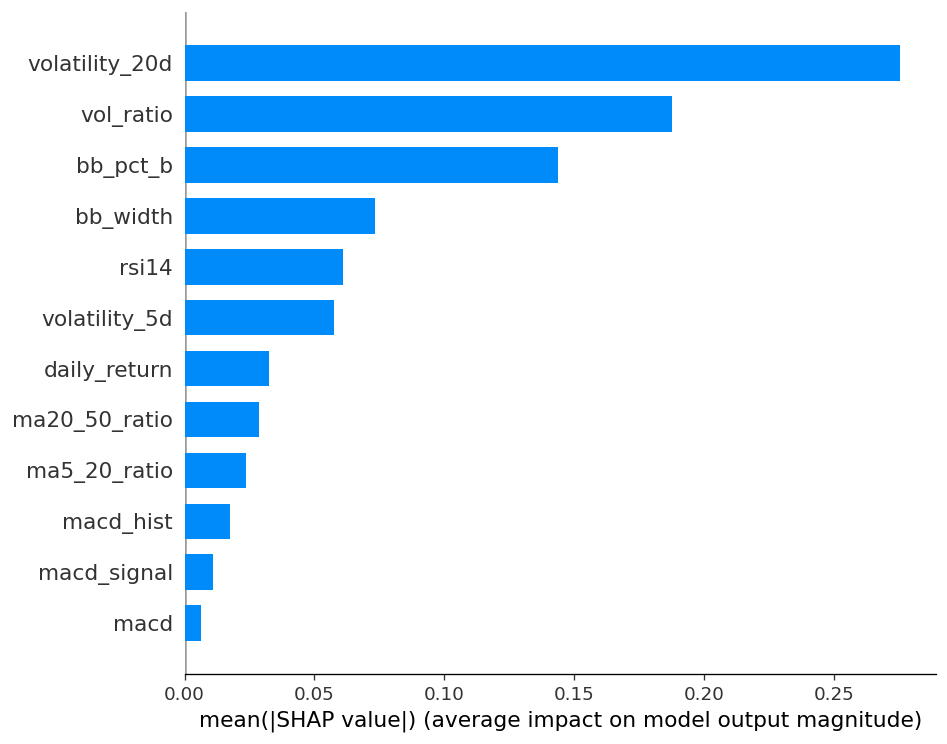

In [69]:
shap.summary_plot(lr_shap_vals, X_test_scaled[:500], feature_names=FEATURE_COLS, plot_type="bar", show=True)

### 9.4 Logistic Regression — SHAP Beeswarm Plot

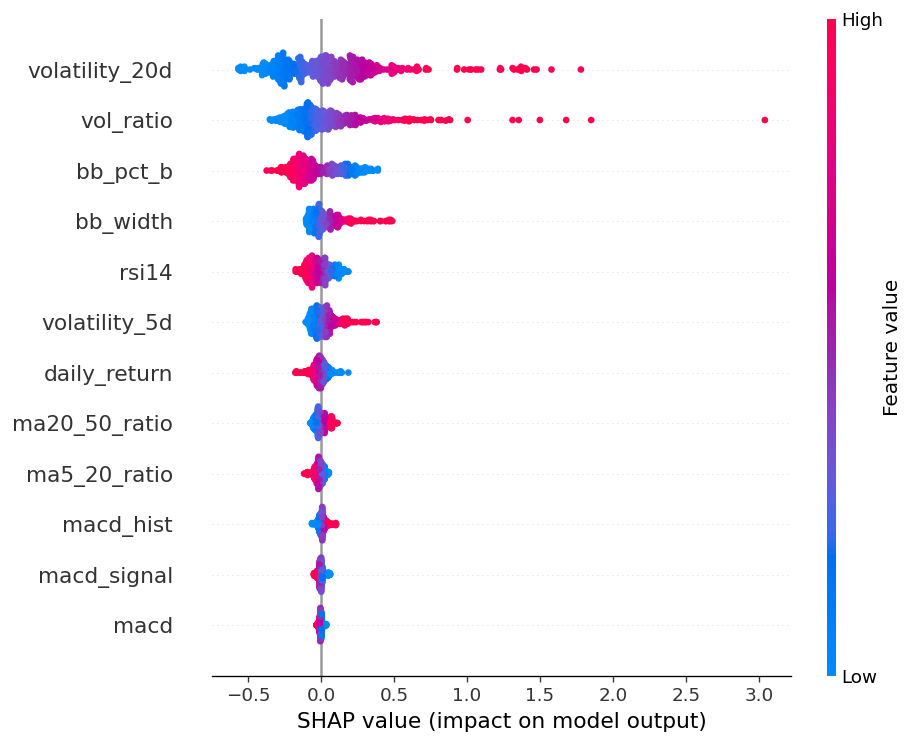

In [70]:
shap.summary_plot(lr_shap_vals, X_test_scaled[:500], feature_names=FEATURE_COLS, show=True)

## 10. Threshold Tuning 
The default decision threshold of 0.5 is not usually optimal for imbalanced datasets. For Class 1 (minority), lowering the threshold increases recall at the cost of precision. To check this, thresholds from 0.1–0.9 are swept for Logistic Regression and Random Forest and F1, Precision, and Recall is plotted to identify the optimal threshold for each model.

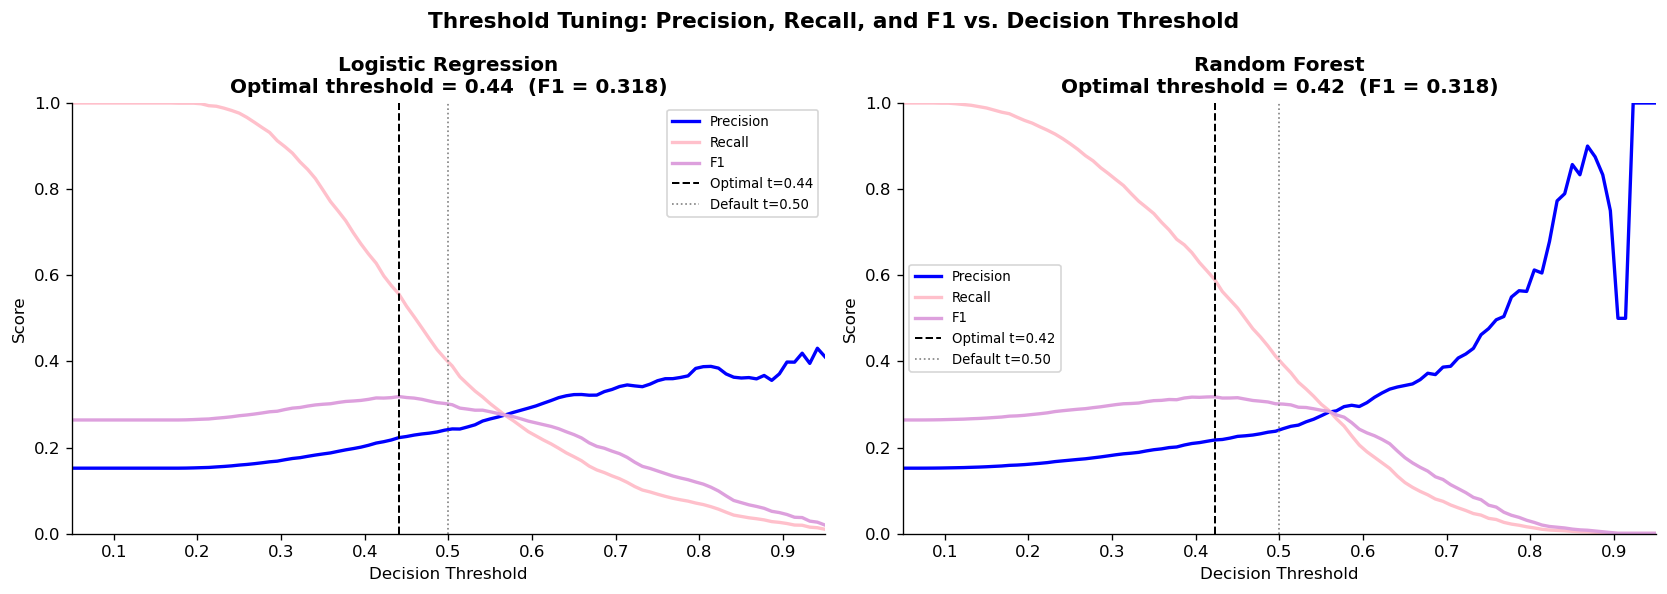

In [72]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
threshold_models = ["Logistic Regression", "Random Forest"]
colors_pr = {"Precision": "blue", "Recall": "pink", "F1": "plum"}

optimal_thresholds = {}

for ax, name in zip(axes, threshold_models):
    pipe = trained[name]
    y_prob = pipe.predict_proba(X_test)[:, 1]
    
    thresholds = np.linspace(0.05, 0.95, 100)
    precisions, recalls, f1s = [], [], []
    
    for t in thresholds:
        y_pred_t = (y_prob >= t).astype(int)
        precisions.append(precision_score(y_test, y_pred_t, zero_division=0))
        recalls.append(recall_score(y_test, y_pred_t, zero_division=0))
        f1s.append(f1_score(y_test, y_pred_t, zero_division=0))
    
    best_idx = np.argmax(f1s)
    best_t = thresholds[best_idx]
    best_f1 = f1s[best_idx]
    optimal_thresholds[name] = {"threshold": best_t, "f1": best_f1}
    
    ax.plot(thresholds, precisions, label="Precision", color=colors_pr["Precision"], lw=2)
    ax.plot(thresholds, recalls, label="Recall", color=colors_pr["Recall"], lw=2)
    ax.plot(thresholds, f1s, label="F1", color=colors_pr["F1"], lw=2)
    ax.axvline(x=best_t, color="black", ls="--", lw=1.2, label=f"Optimal t={best_t:.2f}")
    ax.axvline(x=0.5, color="gray", ls=":", lw=1.0, label="Default t=0.50")
    ax.set_xlabel("Decision Threshold")
    ax.set_ylabel("Score")
    ax.set_title(f"{name}\nOptimal threshold = {best_t:.2f}  (F1 = {best_f1:.3f})", fontweight="bold")
    ax.legend(fontsize=8)
    ax.set_xlim(0.05, 0.95)
    ax.set_ylim(0, 1)

plt.suptitle("Threshold Tuning: Precision, Recall, and F1 vs. Decision Threshold", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [74]:
print("Optimal Thresholds:")
for name, vals in optimal_thresholds.items():
    print(f"{name}: threshold={vals['threshold']:.2f}, F1={vals['f1']:.3f}")

Optimal Thresholds:
Logistic Regression: threshold=0.44, F1=0.318
Random Forest: threshold=0.42, F1=0.318


### 10.1 Evaluate Models at Optimal Thresholds

In [75]:
# re-evaluate at optimal thresholds
threshold_summary = []

for name in threshold_models:
    pipe = trained[name]
    y_prob = pipe.predict_proba(X_test)[:, 1]
    
    # default threshold
    y_pred_default = pipe.predict(X_test)
    
    # optimal threshold
    t_opt   = optimal_thresholds[name]["threshold"]
    y_pred_opt = (y_prob >= t_opt).astype(int)
    
    for label, y_pred in [("Default (0.50)", y_pred_default), (f"Optimal ({t_opt:.2f})", y_pred_opt)]:
        threshold_summary.append({
            "Model": name,
            "Threshold": label,
            "Precision": precision_score(y_test, y_pred, zero_division=0),
            "Recall": recall_score(y_test, y_pred, zero_division=0),
            "F1": f1_score(y_test, y_pred, zero_division=0),
            "Accuracy": accuracy_score(y_test, y_pred),
        })

In [78]:
thresh_df = pd.DataFrame(threshold_summary).set_index(["Model", "Threshold"])
thresh_df.round(4).style.highlight_max(axis=0, color="yellow", subset=["Precision", "Recall", "F1"])

## 11. MLP with Class Weighting
The original MLP had near-zero F1, exhibiting the accuracy paradox since it collapsed to predicting the majority class. To counter this, I added class_weight handling by computing sample weights and passing them to fit(). This process isolates whether the MLP's failure was due to architecture or simply missing imbalance handling.

In [80]:
# MLPClassifier does not support sample_weight so instead, the minority class must get oversampled in the training set to balance classes
idx_0 = np.where(y_train == 0)[0]
idx_1 = np.where(y_train == 1)[0]

idx_1_upsampled = resample(idx_1, replace=True, n_samples=len(idx_0), random_state=RANDOM_STATE)
idx_balanced    = np.concatenate([idx_0, idx_1_upsampled])
np.random.seed(RANDOM_STATE)
np.random.shuffle(idx_balanced)

X_train_bal = X_train[idx_balanced]
y_train_bal = y_train[idx_balanced]

print(f"Balanced training set: {len(X_train_bal):,} rows  |  class ratio: {y_train_bal.mean():.2%} positive")

Balanced training set: 95,414 rows  |  class ratio: 50.00% positive


In [82]:
mlp_cw_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", MLPClassifier(
        hidden_layer_sizes=(128, 64, 32),
        activation="relu", max_iter=300,
        early_stopping=True, validation_fraction=0.1,
        random_state=RANDOM_STATE
    )),
])

mlp_cw_pipe.fit(X_train_bal, y_train_bal)

Pipeline(steps=[('scaler', StandardScaler()),
                ('clf',
                 MLPClassifier(early_stopping=True,
                               hidden_layer_sizes=(128, 64, 32), max_iter=300,
                               random_state=42))])

In [83]:
y_pred_mlp_cw = mlp_cw_pipe.predict(X_test)
y_prob_mlp_cw = mlp_cw_pipe.predict_proba(X_test)[:, 1]

mlp_cw_results = {
    "Model": "MLP (oversampled)",
    "Accuracy": accuracy_score(y_test, y_pred_mlp_cw),
    "Precision": precision_score(y_test, y_pred_mlp_cw, zero_division=0),
    "Recall": recall_score(y_test, y_pred_mlp_cw, zero_division=0),
    "F1": f1_score(y_test, y_pred_mlp_cw, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, y_prob_mlp_cw),
}

orig_mlp = {k: v for k, v in zip(
    ["Model","Accuracy","Precision","Recall","F1","ROC-AUC"],
    ["MLP (original)"] + summary_df.loc["MLP"].tolist()
)}

In [84]:
compare_mlp = pd.DataFrame([orig_mlp, mlp_cw_results]).set_index("Model")
compare_mlp.round(4).style.highlight_max(axis=0, color="yellow")

,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
MLP (original),0.847200,0.456700,0.025800,0.048800,0.655100
MLP (oversampled),0.641200,0.193400,0.428900,0.266600,0.580200


### 11.1 Confusion Matrix: MLP vs. MLP (Class-Weighted)

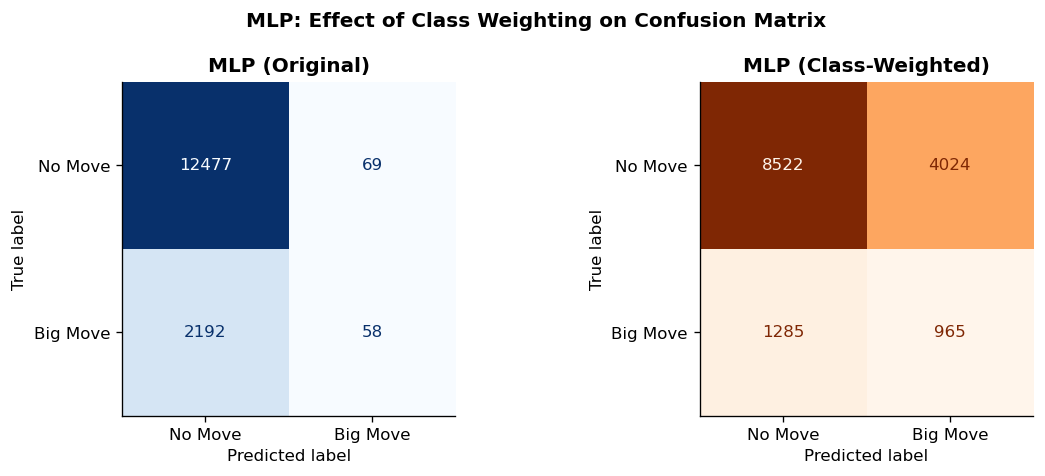

In [85]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# original MLP
y_pred_mlp_orig = trained["MLP"].predict(X_test)
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_mlp_orig, ax=axes[0], colorbar=False,
    display_labels=["No Move", "Big Move"], cmap="Blues"
)
axes[0].set_title("MLP (Original)", fontweight="bold")

# class-weighted MLP
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_mlp_cw, ax=axes[1], colorbar=False,
    display_labels=["No Move", "Big Move"], cmap="Oranges"
)
axes[1].set_title("MLP (Class-Weighted)", fontweight="bold")

plt.suptitle("MLP: Effect of Class Weighting on Confusion Matrix", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()